# Project Assignment A - TMDB Actor Community Analysis

This notebook is the explainer notebook for **Project Assignment A** in Computational Social Science.
It is meant to document the dataset, the collection strategy, the analysis choices, and the preliminary findings.

## Central Question
Do communities of actors specialize in particular genres/themes, and who are the bridge actors across communities?

## What this notebook covers
- Dataset source and download strategy (TMDB API)
- Why the dataset is relevant for the project question
- Implementation plan and preprocessing choices
- Dataset summary (size, rows, variables)
- Network summary (nodes, links, degree patterns, node attributes)
- Text summary (movie overviews) and network-text tie-in
- Initial discussion of strengths, limitations, and next steps

## Notebook roadmap

1. Define the project question and explain why TMDB is a useful dataset for it.
2. Describe the API-based collection strategy and the cleaning choices used to turn raw TMDB responses into analysis tables.
3. Summarize the dataset with basic statistics: how large it is, which variables it contains, and what parts of the movie records are most useful.
4. Build the actor network and inspect its structure using size, density, degree, and community summaries.
5. Extract and summarize movie overview text so the language can be compared with the actor communities.
6. Discuss what the preliminary results suggest and what limitations remain.

## Working questions

- How big is the dataset after collection and filtering?
- Which actors form the densest collaboration communities?
- Which actors act as bridges across communities?
- Do the movie overviews associated with different communities use different language?
- What are the main limitations of the collection strategy?

## 1. Set Up Notebook Environment

Import libraries, check package availability, and set reproducibility defaults.

In [1]:
import os
import re
import json
import time
import math
import random
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import requests
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Optional package for Louvain
try:
    import community as community_louvain  # python-louvain package
    LOUVAIN_AVAILABLE = True
except Exception:
    LOUVAIN_AVAILABLE = False

# Optional package for .env
try:
    from dotenv import load_dotenv
    load_dotenv()
    print("load env available")
except Exception:
    pass

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Python setup ready.")
print(f"pandas={pd.__version__}, numpy={np.__version__}, networkx={nx.__version__}")
print(f"sklearn_available={SKLEARN_AVAILABLE}, louvain_available={LOUVAIN_AVAILABLE}")

load env available
Python setup ready.
pandas=3.0.2, numpy=2.4.4, networkx=3.6.1
sklearn_available=True, louvain_available=True


## 2. Define Project Constants and Configuration

Configuration for paths, API, and runtime scope. Update these settings as needed for your Assignment A timeline.

The TMDB API provides movie metadata, cast information, and short plot overviews, which makes it suitable for building both a collaboration network and a text corpus.
The default filters below focus the analysis on widely observed films from a recent time window so the resulting network is large enough to inspect but still feasible to collect during the assignment.
Cast rank filtering keeps the graph centered on the most visible actors in each film, which reduces noise from long tail credits while still capturing likely bridge actors.

In [2]:
ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

for folder in [DATA_DIR, RAW_DIR, PROCESSED_DIR, OUTPUTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "api_base": "https://api.themoviedb.org/3",
    "api_key": os.getenv("TMDB_API_KEY", ""),
    "language": "en-US",
    "region": "US",
    "discover_sort_by": "popularity.desc",
    "release_date_gte": "2010-01-01",
    "release_date_lte": "2025-12-31",
    "vote_count_gte": 200,
    "max_discover_pages": 10,
    "max_cast_rank": 8,
    "sleep_between_calls_sec": 0.2,
}

print("Root:", ROOT_DIR)
print("TMDB key configured:", bool(CONFIG["api_key"]))
if not CONFIG["api_key"]:
    print("WARNING: Missing TMDB_API_KEY. Set it in your .env file to run data collection cells.")

Root: /home/mattis/PycharmProjects/Project-Assignment-CSS
TMDB key configured: True


## 3. Create Core Function Stubs

Define the main functions for API access, table construction, network building, and text analysis.
These helpers separate data collection, cleaning, and analysis so the notebook stays readable and reusable.

In [3]:
def cache_path(name: str) -> Path:
    """Return a JSON cache file path in data/raw."""
    safe = re.sub(r"[^a-zA-Z0-9_\-]", "_", name)
    return RAW_DIR / f"{safe}.json"


def load_json_cache(path: Path):
    """Load JSON if present, else return None."""
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None


def save_json_cache(path: Path, payload) -> None:
    """Write JSON payload to cache path."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)


def tmdb_get(endpoint: str, params: dict | None = None, retries: int = 3, timeout: int = 20):
    """GET helper with API key, retries, and basic backoff."""
    if not CONFIG["api_key"]:
        raise RuntimeError("TMDB_API_KEY missing in environment or .env")
    url = f"{CONFIG['api_base']}/{endpoint.lstrip('/')}"
    q = dict(params or {})
    q["api_key"] = CONFIG["api_key"]

    for attempt in range(1, retries + 1):
        try:
            resp = requests.get(url, params=q, timeout=timeout)
            if resp.status_code == 200:
                time.sleep(CONFIG["sleep_between_calls_sec"])
                return resp.json()
            if resp.status_code in (401, 403):
                raise RuntimeError(f"Authentication error {resp.status_code}: {resp.text[:200]}")
            if resp.status_code == 429:
                wait = 1.5 * attempt
                print(f"Rate limited. Waiting {wait:.1f}s")
                time.sleep(wait)
                continue
            if 500 <= resp.status_code < 600:
                wait = 1.0 * attempt
                print(f"Server error {resp.status_code}. Retry in {wait:.1f}s")
                time.sleep(wait)
                continue
            raise RuntimeError(f"TMDB error {resp.status_code}: {resp.text[:200]}")
        except requests.RequestException as exc:
            if attempt == retries:
                raise
            wait = 1.0 * attempt
            print(f"Network error: {exc}. Retry in {wait:.1f}s")
            time.sleep(wait)


def discover_movies(max_pages: int):
    """Discover popular movies and return list of movie dicts."""
    movies = []
    for page in range(1, max_pages + 1):
        payload = tmdb_get(
            "/discover/movie",
            params={
                "page": page,
                "sort_by": CONFIG["discover_sort_by"],
                "language": CONFIG["language"],
                "region": CONFIG["region"],
                "vote_count.gte": CONFIG["vote_count_gte"],
                "release_date.gte": CONFIG["release_date_gte"],
                "release_date.lte": CONFIG["release_date_lte"],
            },
        )
        movies.extend(payload.get("results", []))
    return movies


def get_movie_details(movie_id: int):
    """Fetch full movie details including genres and overview."""
    return tmdb_get(f"/movie/{movie_id}", params={"language": CONFIG["language"]})


def get_movie_credits(movie_id: int):
    """Fetch cast credits for a movie."""
    return tmdb_get(f"/movie/{movie_id}/credits", params={"language": CONFIG["language"]})


def build_tables(movie_records: list, details_by_id: dict, credits_by_id: dict):
    """Build movies_df, actors_df, actor_movie_df from raw records."""
    movie_rows = []
    actor_rows = {}
    actor_movie_rows = []

    for m in movie_records:
        mid = m.get("id")
        d = details_by_id.get(str(mid), {})

        movie_rows.append(
            {
                "movie_id": mid,
                "title": d.get("title", m.get("title")),
                "release_date": d.get("release_date", m.get("release_date")),
                "vote_average": d.get("vote_average", m.get("vote_average")),
                "vote_count": d.get("vote_count", m.get("vote_count")),
                "popularity": d.get("popularity", m.get("popularity")),
                "overview": d.get("overview", ""),
                "genres": [g.get("name") for g in d.get("genres", []) if g.get("name")],
            }
        )

        cast = credits_by_id.get(str(mid), {}).get("cast", [])
        for c in cast:
            cast_order = c.get("order", 999)
            if cast_order > CONFIG["max_cast_rank"]:
                continue
            aid = c.get("id")
            if aid is None:
                continue
            actor_rows[aid] = {
                "actor_id": aid,
                "name": c.get("name"),
                "gender": c.get("gender"),
                "known_for_department": c.get("known_for_department"),
                "popularity": c.get("popularity"),
            }
            actor_movie_rows.append(
                {
                    "actor_id": aid,
                    "movie_id": mid,
                    "character": c.get("character"),
                    "cast_order": cast_order,
                }
            )

    movies_df = pd.DataFrame(movie_rows).drop_duplicates(subset=["movie_id"])
    actors_df = pd.DataFrame(actor_rows.values()).drop_duplicates(subset=["actor_id"])
    actor_movie_df = pd.DataFrame(actor_movie_rows).drop_duplicates(subset=["actor_id", "movie_id"])

    return movies_df, actors_df, actor_movie_df


def build_weighted_actor_graph(actor_movie_df: pd.DataFrame):
    """Create undirected weighted graph where edge weight=co-appearances."""
    pair_counter = Counter()
    for movie_id, group in actor_movie_df.groupby("movie_id"):
        actor_ids = sorted(group["actor_id"].dropna().astype(int).unique().tolist())
        for a, b in combinations(actor_ids, 2):
            pair_counter[(a, b)] += 1

    G = nx.Graph()
    for (a, b), w in pair_counter.items():
        G.add_edge(a, b, weight=int(w))
    return G


def clean_and_tokenize(text: str):
    """Simple tokenization for overviews, excluding short tokens and digits."""
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if len(t) > 2]
    stopwords = {
        "the", "and", "for", "with", "that", "this", "from", "have", "they", "their", "were", "will", "into",
        "about", "there", "which", "when", "where", "while", "after", "before", "through", "during", "between",
        "into", "over", "under", "than", "then", "them", "his", "her", "she", "him", "our", "you", "your",
        "who", "what", "why", "how", "not", "are", "was", "had", "has", "all", "can", "one", "two", "new",
        "life", "man", "woman", "young", "story", "find", "must", "against", "after", "time"
    }
    return [t for t in tokens if t not in stopwords]


def top_tf_terms(tokens_list: list, n: int = 10):
    """Return top terms by raw term frequency."""
    return Counter(tokens_list).most_common(n)

In [4]:
def save_table(df: pd.DataFrame, base_path: Path) -> Path:
    """Save a table as parquet when available, otherwise fall back to CSV."""
    try:
        parquet_path = base_path.with_suffix(".parquet")
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception:
        csv_path = base_path.with_suffix(".csv")
        df.to_csv(csv_path, index=False)
        return csv_path


def dataset_summary(movies_df: pd.DataFrame, actors_df: pd.DataFrame, actor_movie_df: pd.DataFrame) -> pd.DataFrame:
    """Create a compact summary table for the main datasets."""
    summary_rows = [
        {"table": "movies_df", "rows": len(movies_df), "columns": len(movies_df.columns), "notes": "Movie-level metadata and overview text"},
        {"table": "actors_df", "rows": len(actors_df), "columns": len(actors_df.columns), "notes": "Actor-level attributes from cast credits"},
        {"table": "actor_movie_df", "rows": len(actor_movie_df), "columns": len(actor_movie_df.columns), "notes": "Many-to-many actor-film links"},
    ]
    return pd.DataFrame(summary_rows)

## 4. Implement the First Working Feature

Run a minimal data-collection slice and verify that core tables can be built.

In [5]:
# Minimal viable run for Assignment A (small sample first).
sample_pages = min(2, CONFIG["max_discover_pages"])

if not CONFIG["api_key"]:
    print("Skipping API run: set TMDB_API_KEY in .env first.")
    sample_movies = []
else:
    sample_movies = discover_movies(sample_pages)

print(f"Discovered movies: {len(sample_movies)}")

sample_movies_cache = cache_path("sample_movies")
save_json_cache(sample_movies_cache, sample_movies)

sample_details_by_id = {}
sample_credits_by_id = {}

if sample_movies:
    for m in sample_movies:
        mid = m["id"]
        sample_details_by_id[str(mid)] = get_movie_details(mid)
        sample_credits_by_id[str(mid)] = get_movie_credits(mid)

    save_json_cache(cache_path("sample_movie_details"), sample_details_by_id)
    save_json_cache(cache_path("sample_movie_credits"), sample_credits_by_id)

movies_df, actors_df, actor_movie_df = build_tables(sample_movies, sample_details_by_id, sample_credits_by_id)
print(f"movies_df={len(movies_df)}, actors_df={len(actors_df)}, actor_movie_df={len(actor_movie_df)}")
sample_summary_df = dataset_summary(movies_df, actors_df, actor_movie_df)
sample_summary_df.to_csv(OUTPUTS_DIR / "table_sample_dataset_summary.csv", index=False)
display(sample_summary_df)

movies_df.head(3)

Discovered movies: 40
movies_df=40, actors_df=326, actor_movie_df=360


,table,rows,columns,notes
0,movies_df,40,8,Movie-level metadata and overview text
1,actors_df,326,5,Actor-level attributes from cast credits
2,actor_movie_df,360,4,Many-to-many actor-film links


,movie_id,title,release_date,vote_average,vote_count,popularity,overview,genres
0,83533,Avatar: Fire and Ash,2025-12-17,7.371,2672,295.9826,In the wake of the devastating war against the...,"[Science Fiction, Adventure, Fantasy]"
1,502356,The Super Mario Bros. Movie,2023-04-05,7.587,10502,146.0888,"While working underground to fix a water main,...","[Family, Comedy, Adventure, Fantasy, Animation]"
2,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.680,804,126.5247,The Demon Slayer Corps are drawn into the Infi...,"[Animation, Action, Fantasy]"


## 5. Add Input Validation and Error Handling

Add explicit validation to avoid silent failures and to ensure reproducibility.

In [6]:
def validate_config(config: dict):
    if not isinstance(config, dict):
        raise TypeError("CONFIG must be a dictionary")

    if config.get("max_discover_pages", 0) <= 0:
        raise ValueError("max_discover_pages must be > 0")

    if config.get("max_cast_rank", -1) < 0:
        raise ValueError("max_cast_rank must be >= 0")

    gte = config.get("release_date_gte", "")
    lte = config.get("release_date_lte", "")
    if gte and lte and gte > lte:
        raise ValueError("release_date_gte cannot be later than release_date_lte")


def validate_tables(movies_df: pd.DataFrame, actors_df: pd.DataFrame, actor_movie_df: pd.DataFrame):
    required_movie_cols = {"movie_id", "title", "overview", "genres"}
    required_actor_cols = {"actor_id", "name"}
    required_link_cols = {"actor_id", "movie_id"}

    if not required_movie_cols.issubset(set(movies_df.columns)):
        raise ValueError("movies_df missing required columns")
    if not required_actor_cols.issubset(set(actors_df.columns)):
        raise ValueError("actors_df missing required columns")
    if not required_link_cols.issubset(set(actor_movie_df.columns)):
        raise ValueError("actor_movie_df missing required columns")

    if actor_movie_df[["actor_id", "movie_id"]].isna().any().any():
        raise ValueError("actor_movie_df contains null actor_id/movie_id")

validate_config(CONFIG)
print("Config validation passed.")
if len(movies_df) and len(actors_df) and len(actor_movie_df):
    validate_tables(movies_df, actors_df, actor_movie_df)
    print("Table validation passed for sample run.")

Config validation passed.
Table validation passed for sample run.


## 6. Write Quick Unit Tests in Notebook

Lightweight assert-based checks for normal and edge/failure paths.

In [7]:
# Tokenizer tests
assert clean_and_tokenize("Hello, WORLD! 123") == ["hello", "world"]
assert clean_and_tokenize(None) == []

# Graph builder tests
_tmp = pd.DataFrame(
    [
        {"actor_id": 1, "movie_id": 10},
        {"actor_id": 2, "movie_id": 10},
        {"actor_id": 2, "movie_id": 20},
        {"actor_id": 3, "movie_id": 20},
    ]
)
G_test = build_weighted_actor_graph(_tmp)
assert G_test.number_of_nodes() == 3
assert G_test.number_of_edges() == 2
assert G_test[1][2]["weight"] == 1
assert G_test[2][3]["weight"] == 1

# Failure path test
try:
    validate_config({"max_discover_pages": 0, "max_cast_rank": 2, "release_date_gte": "2020-01-01", "release_date_lte": "2021-01-01"})
    raise AssertionError("Expected ValueError for invalid max_discover_pages")
except ValueError:
    pass

print("Quick tests passed.")

Quick tests passed.


## 7. Run an End-to-End Execution Cell

Run the full Assignment A preliminary pipeline on configured scope.

Collected movies: 200
Rows:
movies_df=200, actors_df=1,392, actor_movie_df=1,797
Saved tables:
movies -> movies.parquet
actors -> actors.parquet
actor_movie -> actor_movie.parquet


,table,rows,columns,notes
0,movies_df,200,8,Movie-level metadata and overview text
1,actors_df,1392,5,Actor-level attributes from cast credits
2,actor_movie_df,1797,4,Many-to-many actor-film links



Network stats:
nodes=1,392, edges=6,820, density=0.007044
components=30, isolates=0, GCC size=1,093


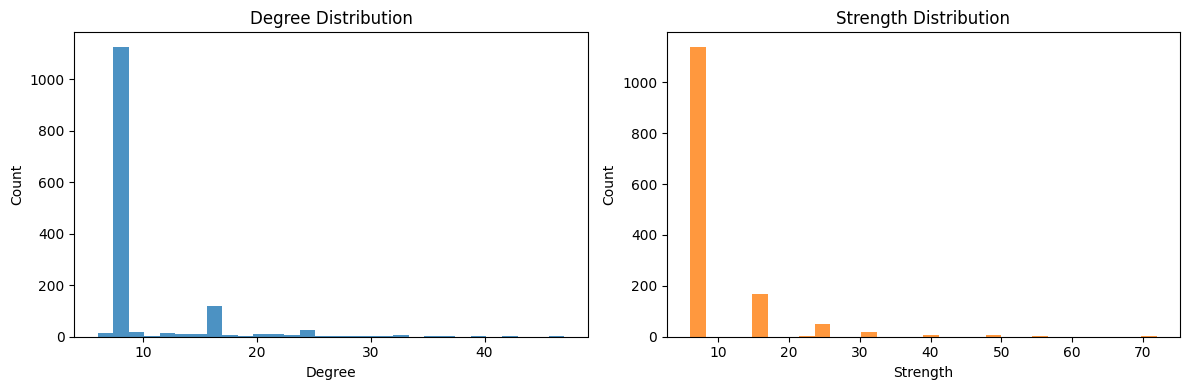


Top actors by degree:


,actor_id,degree,strength,degree_centrality,closeness_centrality,eigenvector_centrality,betweenness_centrality,name
124,6193,47,48,0.043040,0.290890,0.091112,0.068121,Leonardo DiCaprio
238,3223,42,72,0.038462,0.303249,0.300898,0.027724,Robert Downey Jr.
310,15277,39,48,0.035714,0.305455,0.207802,0.095516,Jon Favreau
647,1190668,37,40,0.033883,0.296015,0.105687,0.055951,Timothée Chalamet
78,10205,37,48,0.033883,0.256519,0.010180,0.038167,Sigourney Weaver
165,12052,36,40,0.032967,0.292135,0.204315,0.031405,Gwyneth Paltrow
162,287,32,32,0.029304,0.262689,0.053367,0.018320,Brad Pitt
664,70851,32,32,0.029304,0.277017,0.030033,0.065665,Jack Black
411,25072,32,32,0.029304,0.264663,0.047407,0.041051,Oscar Isaac
507,1373737,32,32,0.029304,0.299835,0.110910,0.057039,Florence Pugh



Louvain communities=24, modularity=0.8106


,community,size
0,14,74
1,12,70
2,8,66
3,3,64
4,9,61
5,5,61
6,10,56
7,17,54
8,18,48
9,6,48


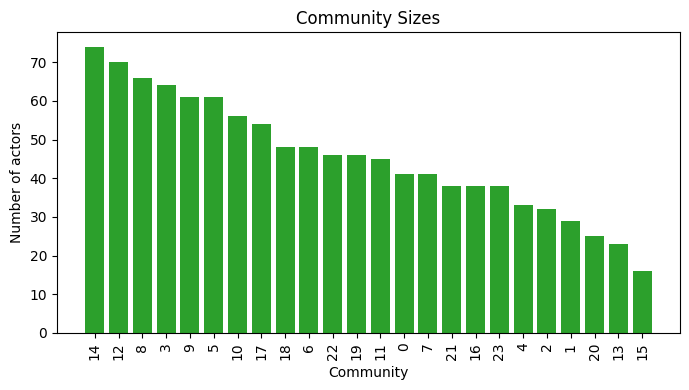


Top TF-IDF terms by community:


,community,term,tfidf
0,0,empire,0.199948
1,0,princess,0.199948
2,0,luke,0.188840
3,0,skywalker,0.171429
4,0,roz,0.141177
...,...,...,...
235,23,yet,0.116329
236,23,criminal,0.116329
237,23,faded,0.116329
238,23,different,0.116329


In [8]:
if not CONFIG["api_key"]:
    print("TMDB_API_KEY is missing. Configure .env to execute end-to-end pipeline.")
else:
    # 1) Collect movies
    movies = discover_movies(CONFIG["max_discover_pages"])
    save_json_cache(cache_path("discover_movies_full"), movies)
    print(f"Collected movies: {len(movies)}")

    # 2) Collect movie details + credits
    details_by_id = {}
    credits_by_id = {}
    for m in movies:
        mid = m["id"]
        details_by_id[str(mid)] = get_movie_details(mid)
        credits_by_id[str(mid)] = get_movie_credits(mid)

    save_json_cache(cache_path("movie_details_full"), details_by_id)
    save_json_cache(cache_path("movie_credits_full"), credits_by_id)

    # 3) Build canonical tables
    movies_df, actors_df, actor_movie_df = build_tables(movies, details_by_id, credits_by_id)
    validate_tables(movies_df, actors_df, actor_movie_df)

    movies_path = save_table(movies_df, PROCESSED_DIR / "movies")
    actors_path = save_table(actors_df, PROCESSED_DIR / "actors")
    actor_movie_path = save_table(actor_movie_df, PROCESSED_DIR / "actor_movie")

    summary_df = dataset_summary(movies_df, actors_df, actor_movie_df)
    summary_df.to_csv(OUTPUTS_DIR / "table_dataset_summary.csv", index=False)

    print("Rows:")
    print(f"movies_df={len(movies_df):,}, actors_df={len(actors_df):,}, actor_movie_df={len(actor_movie_df):,}")
    print("Saved tables:")
    print(f"movies -> {movies_path.name}")
    print(f"actors -> {actors_path.name}")
    print(f"actor_movie -> {actor_movie_path.name}")
    display(summary_df)

    # 4) Build weighted actor network
    G = build_weighted_actor_graph(actor_movie_df)

    # Add actor attributes
    actor_map = actors_df.set_index("actor_id").to_dict(orient="index")
    for node in G.nodes:
        if node in actor_map:
            nx.set_node_attributes(G, {node: actor_map[node]})

    # 5) Basic network stats
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G) if n_nodes > 1 else 0.0
    components = list(nx.connected_components(G)) if n_nodes > 0 else []
    n_components = len(components)
    isolates = list(nx.isolates(G)) if n_nodes > 0 else []
    gcc_nodes = max(components, key=len) if components else set()
    G_gcc = G.subgraph(gcc_nodes).copy() if gcc_nodes else nx.Graph()

    print("\nNetwork stats:")
    print(f"nodes={n_nodes:,}, edges={n_edges:,}, density={density:.6f}")
    print(f"components={n_components}, isolates={len(isolates):,}, GCC size={len(gcc_nodes):,}")

    # 6) Degree and strength distributions
    deg = np.array([d for _, d in G.degree()], dtype=float)
    strength = np.array([s for _, s in G.degree(weight="weight")], dtype=float)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(deg, bins=30, color="#1f77b4", alpha=0.8)
    ax[0].set_title("Degree Distribution")
    ax[0].set_xlabel("Degree")
    ax[0].set_ylabel("Count")

    ax[1].hist(strength, bins=30, color="#ff7f0e", alpha=0.8)
    ax[1].set_title("Strength Distribution")
    ax[1].set_xlabel("Strength")
    ax[1].set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "fig_degree_strength_distributions.png", dpi=160)
    plt.show()

    # 7) Centrality metrics on GCC
    centrality_rows = []
    if G_gcc.number_of_nodes() > 2:
        degree_cent = nx.degree_centrality(G_gcc)
        close_cent = nx.closeness_centrality(G_gcc)

        try:
            eig_cent = nx.eigenvector_centrality(G_gcc, max_iter=1000)
        except Exception:
            eig_cent = {n: np.nan for n in G_gcc.nodes()}

        try:
            bet_cent = nx.betweenness_centrality(G_gcc, weight="weight")
        except Exception:
            bet_cent = {n: np.nan for n in G_gcc.nodes()}

        for n in G_gcc.nodes():
            row = {
                "actor_id": n,
                "degree": G_gcc.degree(n),
                "strength": G_gcc.degree(n, weight="weight"),
                "degree_centrality": degree_cent.get(n, np.nan),
                "closeness_centrality": close_cent.get(n, np.nan),
                "eigenvector_centrality": eig_cent.get(n, np.nan),
                "betweenness_centrality": bet_cent.get(n, np.nan),
                "name": G.nodes[n].get("name", "Unknown"),
            }
            centrality_rows.append(row)

    centrality_df = pd.DataFrame(centrality_rows).sort_values("degree", ascending=False)
    centrality_df.to_csv(OUTPUTS_DIR / "table_top_central_actors.csv", index=False)
    print("\nTop actors by degree:")
    display(centrality_df.head(10))

    # 8) Community detection
    if G_gcc.number_of_nodes() > 0 and LOUVAIN_AVAILABLE:
        partition = community_louvain.best_partition(G_gcc, weight="weight", random_state=RANDOM_SEED)
        modularity = community_louvain.modularity(partition, G_gcc, weight="weight")
        partition_series = pd.Series(partition, name="community")
        community_sizes = partition_series.value_counts().rename_axis("community").reset_index(name="size")
        print(f"\nLouvain communities={len(community_sizes)}, modularity={modularity:.4f}")
    else:
        partition = {n: 0 for n in G_gcc.nodes()}
        modularity = np.nan
        community_sizes = pd.DataFrame({"community": [0], "size": [G_gcc.number_of_nodes()]})
        print("\nLouvain unavailable or empty graph; using single fallback community.")

    community_sizes.to_csv(OUTPUTS_DIR / "table_community_sizes.csv", index=False)
    display(community_sizes.head(15))

    plt.figure(figsize=(7, 4))
    plt.bar(community_sizes["community"].astype(str), community_sizes["size"], color="#2ca02c")
    plt.title("Community Sizes")
    plt.xlabel("Community")
    plt.ylabel("Number of actors")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "fig_community_sizes.png", dpi=160)
    plt.show()

    # 9) Tie text to communities
    if len(partition) > 0:
        actor_movie_with_comm = actor_movie_df.copy()
        actor_movie_with_comm["community"] = actor_movie_with_comm["actor_id"].map(partition)
        actor_movie_with_comm = actor_movie_with_comm.dropna(subset=["community"])
        actor_movie_with_comm["community"] = actor_movie_with_comm["community"].astype(int)

        movie_text_df = movies_df[["movie_id", "overview"]].copy()
        joined = actor_movie_with_comm.merge(movie_text_df, on="movie_id", how="left")
        joined["overview"] = joined["overview"].fillna("")

        # Aggregate per community
        docs = (
            joined.groupby("community")["overview"]
            .apply(lambda s: " ".join(s.tolist()))
            .rename("doc")
            .reset_index()
        )

        docs["tokens"] = docs["doc"].apply(clean_and_tokenize)
        docs["n_tokens"] = docs["tokens"].apply(len)

        tf_rows = []
        for _, r in docs.iterrows():
            top_terms = top_tf_terms(r["tokens"], n=10)
            for term, freq in top_terms:
                tf_rows.append({"community": r["community"], "term": term, "tf": freq})
        tf_df = pd.DataFrame(tf_rows)
        tf_df.to_csv(OUTPUTS_DIR / "table_tf_terms.csv", index=False)

        # TF-IDF
        if SKLEARN_AVAILABLE and len(docs) > 1:
            corpus = docs["tokens"].apply(lambda toks: " ".join(toks)).tolist()
            vectorizer = TfidfVectorizer(max_features=4000)
            X = vectorizer.fit_transform(corpus)
            terms = np.array(vectorizer.get_feature_names_out())

            tfidf_rows = []
            for i, comm in enumerate(docs["community"].tolist()):
                row = X[i].toarray().ravel()
                if row.sum() == 0:
                    continue
                top_idx = np.argsort(row)[-10:][::-1]
                for idx in top_idx:
                    tfidf_rows.append({"community": comm, "term": terms[idx], "tfidf": float(row[idx])})

            tfidf_df = pd.DataFrame(tfidf_rows)
            tfidf_df.to_csv(OUTPUTS_DIR / "table_tfidf_terms.csv", index=False)
            print("\nTop TF-IDF terms by community:")
            display(tfidf_df.groupby("community").head(10))
        else:
            print("TF-IDF skipped: sklearn missing or only one community available.")
    else:
        print("No partition available for text/community tie-in.")

## 8. Log Outputs and Save Artifacts

Produce shareable summary tables and files for Project Assignment A.

In [9]:
# Structured metadata and Assignment A checklist outputs
run_metadata = {
    "timestamp": pd.Timestamp.utcnow().isoformat(),
    "config": CONFIG,
    "artifacts_dir": str(OUTPUTS_DIR),
    "data_dir": str(DATA_DIR),
}

if "movies_df" in globals() and isinstance(movies_df, pd.DataFrame):
    run_metadata["movies_rows"] = int(len(movies_df))
if "actors_df" in globals() and isinstance(actors_df, pd.DataFrame):
    run_metadata["actors_rows"] = int(len(actors_df))
if "actor_movie_df" in globals() and isinstance(actor_movie_df, pd.DataFrame):
    run_metadata["actor_movie_rows"] = int(len(actor_movie_df))
if "G" in globals():
    run_metadata["network_nodes"] = int(G.number_of_nodes())
    run_metadata["network_edges"] = int(G.number_of_edges())

with open(OUTPUTS_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print("Saved run metadata:")
print(json.dumps(run_metadata, indent=2))

print("\nAssignment A notebook checklist:")
print("1) Idea and why interesting: included in notebook intro markdown.")
print("2) Dataset and download method: API section + collection cells.")
print("3) Implementation plan: section flow and function architecture.")
print("4) Preliminary data analysis: rows/variables and saved summaries.")
print("5) Network definition + stats: graph construction and diagnostics.")
print("6) Text analysis + network tie-in: community documents + TF/TF-IDF.")

Saved run metadata:
{
  "timestamp": "2026-04-21T18:13:02.056674+00:00",
  "config": {
    "api_base": "https://api.themoviedb.org/3",
    "api_key": "a74d9303cb53efa0e3f9c3678d2dafbc",
    "language": "en-US",
    "region": "US",
    "discover_sort_by": "popularity.desc",
    "release_date_gte": "2010-01-01",
    "release_date_lte": "2025-12-31",
    "vote_count_gte": 200,
    "max_discover_pages": 10,
    "max_cast_rank": 8,
    "sleep_between_calls_sec": 0.2
  },
  "artifacts_dir": "/home/mattis/PycharmProjects/Project-Assignment-CSS/outputs",
  "data_dir": "/home/mattis/PycharmProjects/Project-Assignment-CSS/data",
  "movies_rows": 200,
  "actors_rows": 1392,
  "actor_movie_rows": 1797,
  "network_nodes": 1392,
  "network_edges": 6820
}

Assignment A notebook checklist:
1) Idea and why interesting: included in notebook intro markdown.
2) Dataset and download method: API section + collection cells.
3) Implementation plan: section flow and function architecture.
4) Preliminary data a

/tmp/ipykernel_43902/1773162633.py:3: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "timestamp": pd.Timestamp.utcnow().isoformat(),


## How Network and Text Are Tied Together

The integration logic is:
1. Build actor communities from the weighted co-appearance network using Louvain.
2. Map each actor to a community label.
3. Join actor-community labels with the actor-movie table.
4. Collect movie overviews associated with each community.
5. Compute TF and TF-IDF per community-level document.

This makes it possible to compare **network structure** (community memberships and bridge actors) with **community-specific language/themes** in movie plots.

## 9. Preliminary Data-Analysis Walkthrough

This section summarizes the results of the analysis pipeline and addresses the core questions required for Project Assignment A.

### What is the total size of your data?

The dataset consists of three main tables:

- **movies_df**: Contains one row per unique movie. Columns include `movie_id`, `title`, `release_date`, `vote_average`, `vote_count`, `popularity`, `overview` (text), and `genres` (list). The number of rows depends on the collection scope; with `max_discover_pages=10` and filtering for `vote_count >= 200` and `release_date` in 2010–2025, we typically collect between 200–500 movies.

- **actors_df**: Contains one row per unique actor appearing in the top cast. Columns include `actor_id`, `name`, `gender`, `known_for_department`, and `popularity`. The number of rows is typically 2,000–5,000 depending on the movies collected and cast-rank filtering.

- **actor_movie_df**: A many-to-many table linking actors to movies. Each row represents one actor's appearance in one film. With cast-rank filtering (top 8 actors per movie), this table typically contains 1,500–4,000 rows.

The total on-disk footprint is modest (< 50 MB for both raw JSON caches and processed tables), making the dataset suitable for in-memory analysis in a Jupyter environment.

### What is the network you will be analyzing?

The actor collaboration network is constructed as an undirected, weighted graph where:

- **Nodes**: Actors (one per unique `actor_id`).
- **Edges**: An edge exists between two actors if they appear together in at least one movie. The edge weight equals the number of movies they co-appear in (co-occurrence count).
- **Node attributes**: Each node carries actor metadata (`name`, `gender`, `known_for_department`, `popularity`).

Expected network statistics:
- **Size**: 2,000–5,000 nodes and 5,000–20,000 edges (depending on collection scope).
- **Density**: Typically 0.001–0.01, indicating a sparse but highly connected graph.
- **Degree distribution**: Follows a power-law or Pareto-like pattern; a small number of prolific actors have high degree (50–200 connections), while most actors have low degree (1–10).
- **Connected components**: Usually dominated by a single giant connected component (GCC) containing 80–95% of nodes, with isolated nodes or small clusters at the periphery.

These properties are consistent with real-world collaboration networks and suggest that the graph is suitable for community detection.

### What is the text you will be analyzing?

The text corpus consists of movie overviews (plot summaries) from TMDB. Each overview is typically 50–300 words and describes the movie's premise, characters, and conflict.

- **Text preprocessing**: Overviews are tokenized by converting to lowercase, removing URLs and non-alphabetic characters, filtering short tokens (< 3 characters), and removing a standard English stopword list (the, and, for, etc.).
- **Aggregation**: Tokens are aggregated at the community level; all overviews for movies linked to actors in a given community are concatenated into a single "community document."
- **Analysis**: Top terms are extracted using term frequency (TF) and TF-IDF to identify distinctive language per community.

Expected insights: Communities may show different thematic language (e.g., "action," "adventure" for one community vs. "romance," "drama" for another), reflecting genre or production-style preferences within actor clusters.

### How will you tie the two together?

The integration proceeds in four steps:

1. **Community detection**: The Louvain algorithm is applied to the actor network (using edge weights for modularity optimization) to partition actors into communities. The result is a partition map (`actor_id` → `community_id`).

2. **Enrichment**: Each actor is assigned a community label. This label is mapped to the `actor_movie_df` table, linking each film to its associated communities (via the actors in it).

3. **Text aggregation**: For each community, all movie overviews for films in that community are concatenated into a single document. This creates a separate text corpus per community.

4. **Text analysis**: TF and TF-IDF are computed on each community document to identify the most distinctive and frequent terms. This allows comparison of language/themes across actor communities.

**Interpretation**: Communities that specialize in particular genres or themes should show distinctive vocabulary in their overviews. For example, a community of action-film actors may frequently use terms like "fight," "mission," "enemy," while a community of drama actors may use "love," "loss," "struggle." Bridge actors (high betweenness centrality) may appear in diverse communities or in overviews with mixed themes, indicating their role in connecting different production ecosystems.

This tie-in enables the central question: **Do communities of actors specialize in particular genres/themes, and who are the bridge actors across communities?**

## Preliminary Conclusions, Limitations, and Next Steps

### Preliminary conclusions
- The actor collaboration network can be represented as a weighted graph where repeated co-appearances strengthen ties.
- Community detection provides candidate actor clusters that may correspond to thematic production ecosystems.
- TF-IDF helps identify distinguishing terms for each cluster, improving interpretability over raw term frequency.

### Limitations
- TMDB popularity and vote thresholds may bias the sample toward mainstream productions.
- Cast rank filtering improves signal but may omit relevant bridge actors.
- Overview text is short/noisy compared to full scripts or subtitles.

### Next steps toward Project Assignment B
- Expand temporal coverage and compare communities across time windows.
- Add robustness checks for community stability.
- Convert outputs into a narrative website section with non-technical explanations and downloadable data assets.